# Creditworthiness Prediction using Machine Learning
Using CreditWorthiness.xlsx

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve


In [2]:
df=pd.read_excel('CreditWorthiness.xlsx')
df.head()

,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,InRate,MSG,Oparties,...,Prop,age,inPlans,Htype,NumCred,JobType,Ndepend,telephone,foreign,creditScore
0,0 <= Rs. < 2000,9,all settled till now,Business,13790,Rs. < 1000,1 to 4 years,2,married or widowed male,no one,...,real estate,27,bank,own,1,employee with official position,1,yes,no,good
1,0 <= Rs. < 2000,15,dues not paid earlier,electronics,15250,no savings account,more than 7 years,4,single male,"yes, guarantor",...,real estate,50,none,own,2,employee with official position,1,yes,no,good
2,0 <= Rs. < 2000,36,none taken/all settled,Business,19410,Rs. < 1000,more than 7 years,4,single male,no one,...,Unknown,61,none,free,1,"employed either in management, self or in high...",1,yes,no,bad
3,0 <= Rs. < 2000,48,none taken/all settled,Business,144090,Rs. < 1000,1 to 4 years,2,single male,no one,...,Other cars etc.,25,none,own,1,employee with official position,1,yes,no,bad
4,no checking account,24,all settled till now,electronics,31690,Rs. < 1000,less than 1 year,4,divorced or separated or married female,no one,...,life insurance/building society,26,none,own,1,employee with official position,1,yes,no,good


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Cbal         1000 non-null   str  
 1   Cdur         1000 non-null   int64
 2   Chist        1000 non-null   str  
 3   Cpur         1000 non-null   str  
 4   Camt         1000 non-null   int64
 5   Sbal         1000 non-null   str  
 6   Edur         1000 non-null   str  
 7   InRate       1000 non-null   int64
 8   MSG          1000 non-null   str  
 9   Oparties     1000 non-null   str  
 10  Rdur         1000 non-null   str  
 11  Prop         1000 non-null   str  
 12  age          1000 non-null   int64
 13  inPlans      1000 non-null   str  
 14  Htype        1000 non-null   str  
 15  NumCred      1000 non-null   int64
 16  JobType      1000 non-null   str  
 17  Ndepend      1000 non-null   int64
 18  telephone    1000 non-null   str  
 19  foreign      1000 non-null   str  
 20  creditScore  1000 no

Cbal           0
Cdur           0
Chist          0
Cpur           0
Camt           0
Sbal           0
Edur           0
InRate         0
MSG            0
Oparties       0
Rdur           0
Prop           0
age            0
inPlans        0
Htype          0
NumCred        0
JobType        0
Ndepend        0
telephone      0
foreign        0
creditScore    0
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode all categorical (object) columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Check the data types after encoding
print(df.dtypes)
df.head()

Cbal             int64
Cdur             int64
Chist            int64
Cpur             int64
Camt             int64
Sbal             int64
Edur             int64
InRate           int64
MSG              int64
Oparties         int64
Rdur             int64
Prop             int64
age              int64
inPlans          int64
Htype            int64
NumCred          int64
JobType          int64
Ndepend          int64
telephone        int64
foreign          int64
creditScore      int64
AmtPerMonth    float64
dtype: object


C:\Users\PRASANTH\AppData\Local\Temp\ipykernel_19752\832952225.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,InRate,MSG,Oparties,...,age,inPlans,Htype,NumCred,JobType,Ndepend,telephone,foreign,creditScore,AmtPerMonth
0,1,9,1,0,13790,2,0,2,2,0,...,27,0,1,1,1,1,1,0,1,1532.222222
1,1,15,2,3,15250,4,3,4,3,2,...,50,1,1,2,1,1,1,0,1,1016.666667
2,1,36,3,0,19410,2,3,4,3,0,...,61,1,0,1,0,1,1,0,0,539.166667
3,1,48,3,0,144090,2,0,2,3,0,...,25,1,1,1,1,1,1,0,0,3001.875000
4,3,24,1,3,31690,2,2,4,1,0,...,26,1,1,1,1,1,1,0,1,1320.416667


In [10]:
df['AmtPerMonth']=df['Camt']/df['Cdur']
X=df.drop('creditScore',axis=1)
y=df['creditScore']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
pred=lr.predict(X_test)
prob=lr.predict_proba(X_test)[:,1]
print('Accuracy',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))
print('ROC-AUC',roc_auc_score(y_test,prob))

Accuracy 0.75
              precision    recall  f1-score   support

           0       0.62      0.43      0.51        60
           1       0.78      0.89      0.83       140

    accuracy                           0.75       200
   macro avg       0.70      0.66      0.67       200
weighted avg       0.74      0.75      0.74       200

[[ 26  34]
 [ 16 124]]
ROC-AUC 0.7845238095238095


c:\Users\PRASANTH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred=dt.predict(X_test)
prob=dt.predict_proba(X_test)[:,1]
print('Accuracy',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))
print('ROC-AUC',roc_auc_score(y_test,prob))

Accuracy 0.7
              precision    recall  f1-score   support

           0       0.50      0.45      0.47        60
           1       0.77      0.81      0.79       140

    accuracy                           0.70       200
   macro avg       0.64      0.63      0.63       200
weighted avg       0.69      0.70      0.70       200

[[ 27  33]
 [ 27 113]]
ROC-AUC 0.6285714285714286


In [13]:
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
pred=rf.predict(X_test)
prob=rf.predict_proba(X_test)[:,1]
print('Accuracy',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))
print('ROC-AUC',roc_auc_score(y_test,prob))

Accuracy 0.81
              precision    recall  f1-score   support

           0       0.74      0.57      0.64        60
           1       0.83      0.91      0.87       140

    accuracy                           0.81       200
   macro avg       0.79      0.74      0.76       200
weighted avg       0.80      0.81      0.80       200

[[ 34  26]
 [ 12 128]]
ROC-AUC 0.8539880952380953


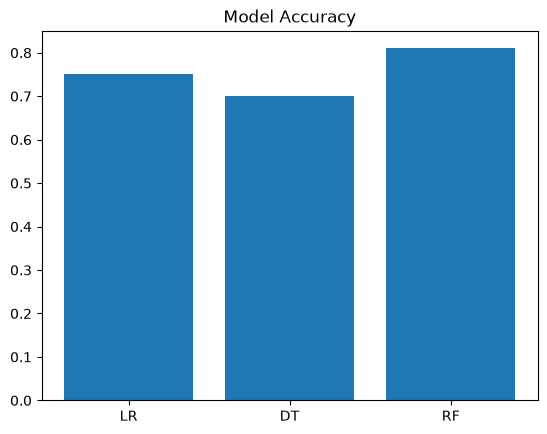

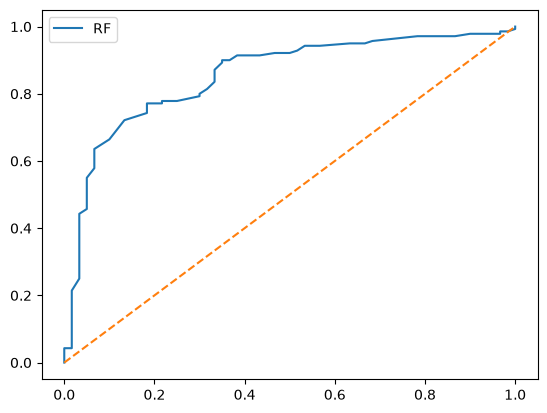

        Feature  Importance
20  AmtPerMonth    0.117122
4          Camt    0.115895
0          Cbal    0.105650
12          age    0.091876
1          Cdur    0.082651
3          Cpur    0.055862
2         Chist    0.047469
5          Sbal    0.046522
6          Edur    0.043165
7        InRate    0.036996
10         Rdur    0.036965
11         Prop    0.036629
8           MSG    0.031522
13      inPlans    0.028648
16      JobType    0.027724
14        Htype    0.023867
15      NumCred    0.021094
18    telephone    0.018629
9      Oparties    0.016673
17      Ndepend    0.012375
19      foreign    0.002667


In [14]:
models=['LR','DT','RF']
acc=[]
for m in [lr,dt,rf]:
    acc.append(accuracy_score(y_test,m.predict(X_test)))
plt.bar(models,acc)
plt.title('Model Accuracy')
plt.show()

fpr,tpr,_=roc_curve(y_test,rf.predict_proba(X_test)[:,1])
plt.plot(fpr,tpr,label='RF')
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

imp=pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_}).sort_values('Importance',ascending=False)
print(imp)

## Conclusion
Random Forest achieved the best performance on this dataset.